In [4]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Set display and plot style
plt.rcParams["figure.figsize"] = (10,5)
sns.set(style="whitegrid")


In [5]:
# Load dataset
df = pd.read_csv("retail_store_inventory.csv")

# Display basic info
print("Dataset shape:", df.shape)
df.info()


Dataset shape: (73100, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73100 entries, 0 to 73099
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                73100 non-null  object 
 1   Store ID            73100 non-null  object 
 2   Product ID          73100 non-null  object 
 3   Category            73100 non-null  object 
 4   Region              73100 non-null  object 
 5   Inventory Level     73100 non-null  int64  
 6   Units Sold          73100 non-null  int64  
 7   Units Ordered       73100 non-null  int64  
 8   Demand Forecast     73100 non-null  float64
 9   Price               73100 non-null  float64
 10  Discount            73100 non-null  int64  
 11  Weather Condition   73100 non-null  object 
 12  Holiday/Promotion   73100 non-null  int64  
 13  Competitor Pricing  73100 non-null  float64
 14  Seasonality         73100 non-null  object 
dtypes: float64(3), int64(5), o

In [6]:
df.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
0,01-01-2022,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,Rainy,0,29.69,Autumn
1,01-01-2022,S001,P0002,Toys,South,204,150,66,144.04,63.01,20,Sunny,0,66.16,Autumn
2,01-01-2022,S001,P0003,Toys,West,102,65,51,74.02,27.99,10,Sunny,1,31.32,Summer
3,01-01-2022,S001,P0004,Toys,North,469,61,164,62.18,32.72,10,Cloudy,1,34.74,Autumn
4,01-01-2022,S001,P0005,Electronics,East,166,14,135,9.26,73.64,0,Sunny,0,68.95,Summer


In [7]:
df.tail()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
73095,01-01-2024,S005,P0016,Furniture,East,96,8,127,18.46,73.73,20,Snowy,0,72.45,Winter
73096,01-01-2024,S005,P0017,Toys,North,313,51,101,48.43,82.57,10,Cloudy,0,83.78,Autumn
73097,01-01-2024,S005,P0018,Clothing,West,278,36,151,39.65,11.11,10,Rainy,0,10.91,Winter
73098,01-01-2024,S005,P0019,Toys,East,374,264,21,270.52,53.14,20,Rainy,0,55.80,Spring
73099,01-01-2024,S005,P0020,Groceries,East,117,6,165,2.33,78.39,20,Rainy,1,79.52,Spring


In [8]:
print(df.columns)

Index(['Date', 'Store ID', 'Product ID', 'Category', 'Region',
       'Inventory Level', 'Units Sold', 'Units Ordered', 'Demand Forecast',
       'Price', 'Discount', 'Weather Condition', 'Holiday/Promotion',
       'Competitor Pricing', 'Seasonality'],
      dtype='object')


In [9]:
# Convert date column
df["Date"] = pd.to_datetime(df["Date"], format="%d-%m-%Y", errors='coerce')

In [10]:
# Extract year, month, day
df["year"] = df["Date"].dt.year
df["month"] = df["Date"].dt.month
df["day"] = df["Date"].dt.day
df["weekend"] = df["Date"].dt.weekday.isin([5,6]).astype(int)


In [11]:
# Check for nulls
print("Missing values:\n", df.isnull().sum())


Missing values:
 Date                  0
Store ID              0
Product ID            0
Category              0
Region                0
Inventory Level       0
Units Sold            0
Units Ordered         0
Demand Forecast       0
Price                 0
Discount              0
Weather Condition     0
Holiday/Promotion     0
Competitor Pricing    0
Seasonality           0
year                  0
month                 0
day                   0
weekend               0
dtype: int64


In [12]:
# Drop rows with missing critical columns
df = df.dropna(subset=["Store ID", "Product ID", "Inventory Level", "Units Sold"])

In [13]:
# Convert and extract date parts
df["Date"] = pd.to_datetime(df["Date"], errors="coerce", dayfirst=True)
df["year"] = df["Date"].dt.year
df["month"] = df["Date"].dt.month
df["day"] = df["Date"].dt.day
df["weekday"] = df["Date"].dt.weekday
df["weekend"] = df["weekday"].isin([5,6]).astype(int)


In [14]:
# Preview result
print(df.head())

        Date Store ID Product ID     Category Region  Inventory Level  \
0 2022-01-01     S001      P0001    Groceries  North              231   
1 2022-01-01     S001      P0002         Toys  South              204   
2 2022-01-01     S001      P0003         Toys   West              102   
3 2022-01-01     S001      P0004         Toys  North              469   
4 2022-01-01     S001      P0005  Electronics   East              166   

   Units Sold  Units Ordered  Demand Forecast  Price  Discount  \
0         127             55           135.47  33.50        20   
1         150             66           144.04  63.01        20   
2          65             51            74.02  27.99        10   
3          61            164            62.18  32.72        10   
4          14            135             9.26  73.64         0   

  Weather Condition  Holiday/Promotion  Competitor Pricing Seasonality  year  \
0             Rainy                  0               29.69      Autumn  2022   
1   

In [15]:
print(df.dtypes)

Date                  datetime64[ns]
Store ID                      object
Product ID                    object
Category                      object
Region                        object
Inventory Level                int64
Units Sold                     int64
Units Ordered                  int64
Demand Forecast              float64
Price                        float64
Discount                       int64
Weather Condition             object
Holiday/Promotion              int64
Competitor Pricing           float64
Seasonality                   object
year                           int32
month                          int32
day                            int32
weekend                        int32
weekday                        int32
dtype: object


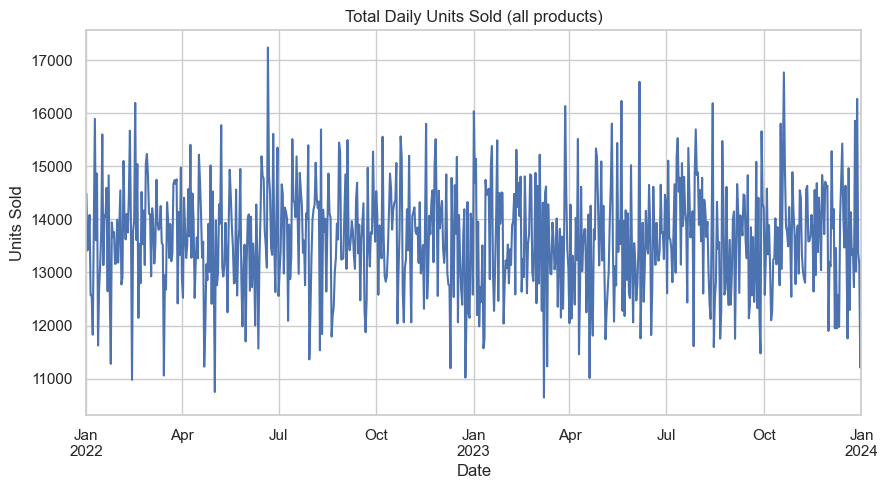

In [16]:
# Daily aggregated sales across all products (quick view)
daily = df.groupby('Date')['Units Sold'].sum()
daily.plot(title="Total Daily Units Sold (all products)")
plt.ylabel("Units Sold")
plt.show()

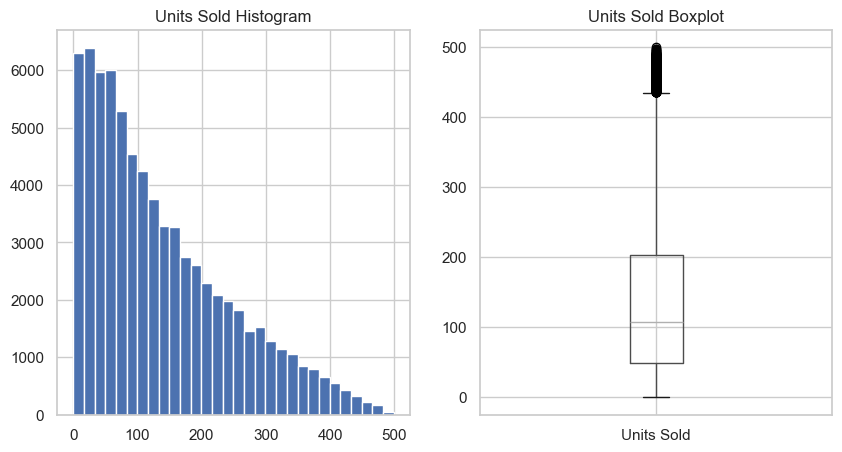

In [17]:
# Example: Units Sold histogram + boxplot
plt.subplot(1,2,1)
df['Units Sold'].hist(bins=30)
plt.title('Units Sold Histogram')

plt.subplot(1,2,2)
df.boxplot(column=['Units Sold'])
plt.title('Units Sold Boxplot')
plt.show()

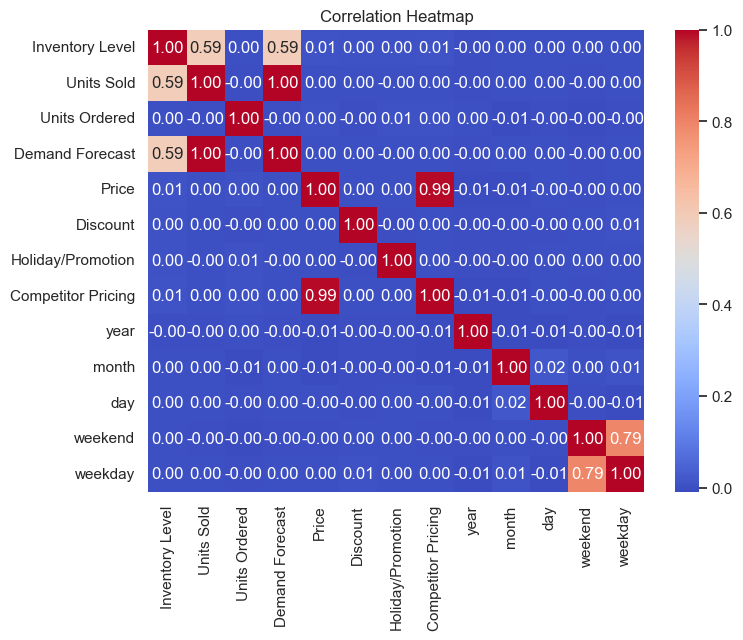

In [18]:
plt.figure(figsize=(8,6))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


In [19]:
#slecting required features
features=['Store ID','Product ID','year','month']
targets='Inventory Level'
X=df[features]
y=df[targets]

In [20]:
import pandas as pd
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')

# Aggregate duplicates if any
df = df.groupby(['Store ID', 'Product ID', 'Date'], as_index=False)['Inventory Level'].mean()


In [21]:
results_hw = []  # store results for all combinations

grouped = df.groupby(['Store ID', 'Product ID'])


In [22]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_squared_error
import numpy as np

results_hw = []  # to store forecast results

# Group by Store ID and Product ID
grouped = df.groupby(["Store ID", "Product ID"])

for (s, p), group in grouped:
    # Prepare the time series (Inventory Level per day)
    series = group.set_index("Date").sort_index()["Inventory Level"].asfreq("D").fillna(0)
    
    # Skip series that are too short
    if len(series) < 60:
        continue

    # Split into training and testing (last 30 days for testing)
    horizon = 30
    train, test = series[:-horizon], series[-horizon:]
    
    try:
        # Train the Holt-Winters model
        model = ExponentialSmoothing(train, trend="add", seasonal="add", seasonal_periods=7)
        fit = model.fit(optimized=True)
        
        # Forecast for test period
        forecast = fit.forecast(horizon)
        
        # Evaluate accuracy
        rmse = np.sqrt(mean_squared_error(test, forecast))
        accuracy = 100 - (rmse / test.mean() * 100)
        
        # Save results
        results_hw.append({
            "Store ID": s,
            "Product ID": p,
            "RMSE": round(rmse, 2),
            "Actual Mean": round(test.mean(), 2),
            "Forecast Mean": round(forecast.mean(), 2),
            "Accuracy (%)": round(accuracy, 2)
        })
        
    except Exception as e:
        print(f"⚠️ Error on Store {s}, Product {p}: {e}")

print("✅ Forecasting complete.")




✅ Forecasting complete.


In [23]:
# Prepare list to store results
results_hw = []

print("📦 Starting Holt-Winters forecasting for all store-product pairs...")


📦 Starting Holt-Winters forecasting for all store-product pairs...


In [24]:
# Group by Store ID and Product ID
grouped = df.groupby(["Store ID", "Product ID"])
print("Total groups found:", len(grouped))


Total groups found: 100


In [25]:
# Convert list of results into a DataFrame
results_hw_df = pd.DataFrame(results_hw)

# Print all results
print(results_hw_df)


Empty DataFrame
Columns: []
Index: []


📊 Evaluation Results
------------------------
RMSE: 14.49
Accuracy: 92.66 %
SMAPE: 6.33 %
Approx. Accuracy (from SMAPE): 93.67 %


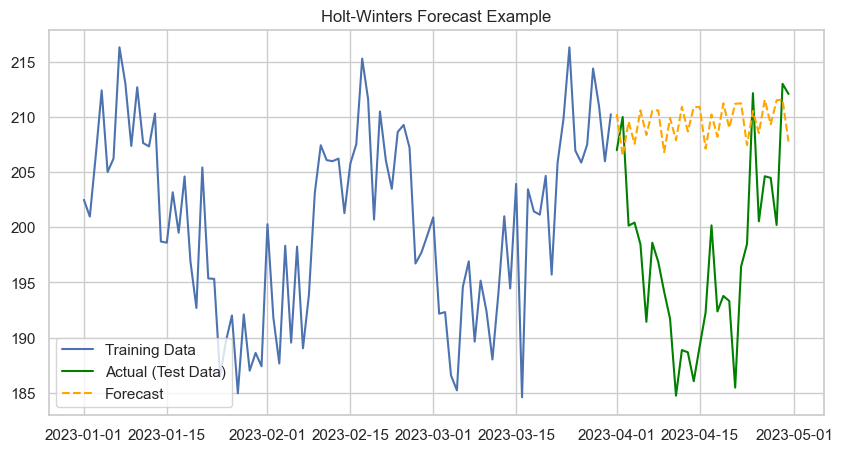

In [27]:
import pandas as pd
import numpy as np
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# ----------------------------
# 1️⃣ Create sample time series
# ----------------------------
np.random.seed(42)
dates = pd.date_range(start="2023-01-01", periods=120, freq="D")  # 120 days
data = 200 + 10*np.sin(np.arange(120)/6) + np.random.normal(0, 5, 120)  # seasonal pattern + noise

series = pd.Series(data, index=dates)

# ----------------------------
# 2️⃣ Split into Train & Test
# ----------------------------
horizon = 30
train, test = series[:-horizon], series[-horizon:]

# ----------------------------
# 3️⃣ Train Holt-Winters Model
# ----------------------------
model = ExponentialSmoothing(train, trend='add', seasonal='add', seasonal_periods=7)
fit = model.fit(optimized=True)

# ----------------------------
# 4️⃣ Forecast for next 30 days
# ----------------------------
forecast = fit.forecast(horizon)

# ----------------------------
# 5️⃣ Evaluate Accuracy
# ----------------------------
rmse = np.sqrt(mean_squared_error(test, forecast))
accuracy = 100 - (rmse / test.mean() * 100)

def smape(actual, forecast):
    actual, forecast = np.array(actual), np.array(forecast)
    return 100 * np.mean(2 * np.abs(forecast - actual) / (np.abs(actual) + np.abs(forecast)))

smape_value = smape(test, forecast)

print("📊 Evaluation Results")
print("------------------------")
print(f"RMSE: {round(rmse, 2)}")
print(f"Accuracy: {round(accuracy, 2)} %")
print(f"SMAPE: {round(smape_value, 2)} %")
print(f"Approx. Accuracy (from SMAPE): {round(100 - smape_value, 2)} %")

# ----------------------------
# 6️⃣ Plot Actual vs Forecast
# ----------------------------
plt.figure(figsize=(10,5))
plt.plot(train, label="Training Data")
plt.plot(test, label="Actual (Test Data)", color='green')
plt.plot(forecast, label="Forecast", color='orange', linestyle='--')
plt.title("Holt-Winters Forecast Example")
plt.legend()
plt.show()


In [29]:
from sklearn.metrics import mean_squared_error
import numpy as np

# 🔹 Calculate RMSE
rmse = np.sqrt(mean_squared_error(test, forecast))

# 🔹 Calculate Forecast Accuracy (%)
accuracy = 100 - (rmse / test.mean() * 100)

print(f"RMSE: {round(rmse, 2)}")
print(f"Forecast Accuracy: {round(accuracy, 2)} %")


RMSE: 14.49
Forecast Accuracy: 92.66 %
